# 04 — Model Training (VaxFlow)

1. **Demand Forecasting (baseline)** — SMA vs Exponential Smoothing (จูน α)  
2. **Model Comparison** — RandomForest · XGBoost · LightGBM · Neural Network (MLP) จูนด้วย **Optuna**  
3. **Transportation Model** — Linear Programming หาแผนโอนย้ายต้นทุนต่ำสุด (Proposal §4.3)

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import linprog

ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
VAX = ROOT / 'data' / 'vaccine'
OUT = VAX / 'outputs'; OUT.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(VAX / 'features' / 'demand_features.csv', parse_dates=['date'])

In [18]:
# ── ทำให้ matplotlib แสดงภาษาไทยได้ (ลงทะเบียนฟอนต์ไทยที่เจอในเครื่อง) ──
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path as _Path
_font_files = [
    'C:/Windows/Fonts/THSarabunNew.ttf', 'C:/Windows/Fonts/tahoma.ttf',
    'C:/Windows/Fonts/LeelawUI.ttf', 'C:/Windows/Fonts/angsa.ttf',
    '/usr/share/fonts/truetype/tlwg/Sarabun.ttf',
    '/usr/share/fonts/truetype/noto/NotoSansThai-Regular.ttf',
    '/Library/Fonts/Tahoma.ttf', '/System/Library/Fonts/Supplemental/Tahoma.ttf',
]
for _p in _font_files:
    if _Path(_p).exists():
        try: font_manager.fontManager.addfont(_p)
        except Exception: pass
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _name in ['TH Sarabun New', 'Tahoma', 'Leelawadee UI', 'Sarabun', 'Angsana New', 'Noto Sans Thai']:
    if _name in _avail:
        plt.rcParams['font.family'] = _name
        break
plt.rcParams['axes.unicode_minus'] = False   # กันเครื่องหมายลบเพี้ยน
print('matplotlib font ->', plt.rcParams['font.family'])

matplotlib font -> ['Tahoma']


## 1) Demand Forecasting — จูน α ของ Exponential Smoothing

แบ่ง train/test ตามเวลา (80/20) แล้ววัด RMSE ของ SMA-7 เทียบกับ ES ที่ α ต่าง ๆ

In [19]:
def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def es_forecast(series, alpha):
    f = series.iloc[0]
    out = []
    for t in range(len(series)):
        out.append(f)
        f = alpha * series.iloc[t] + (1 - alpha) * f
    return np.array(out)

alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7]
results = []
for (hid, pid), g in feat.groupby(['hospital_id', 'product_id']):
    g = g.sort_values('date'); cut = int(len(g) * 0.8)
    test = g.iloc[cut:]
    sma_rmse = rmse(test['demand'], test['sma_7'])
    best_a, best_r = None, np.inf
    for a in alphas:
        pred = es_forecast(g['demand'], a)[cut:]
        r = rmse(test['demand'], pred)
        if r < best_r: best_a, best_r = a, r
    results.append({'hospital_id': hid, 'product_id': pid,
                    'sma7_rmse': round(sma_rmse, 2), 'best_alpha': best_a,
                    'es_rmse': round(best_r, 2),
                    'winner': 'ES' if best_r < sma_rmse else 'SMA'})
fc = pd.DataFrame(results)
print(fc['winner'].value_counts().to_dict())
fc

{'SMA': 6, 'ES': 4}


,hospital_id,product_id,sma7_rmse,best_alpha,es_rmse,winner
0,HOSP_001,VAX_MDV_01,5.09,0.1,5.17,SMA
1,HOSP_001,VAX_MRNA_01,5.89,0.1,5.96,SMA
2,HOSP_002,VAX_MDV_01,9.54,0.7,8.99,ES
3,HOSP_002,VAX_MRNA_01,5.19,0.3,5.78,SMA
4,HOSP_003,VAX_MDV_01,21.56,0.5,20.57,ES
5,HOSP_003,VAX_MRNA_01,17.82,0.5,16.39,ES
6,HOSP_004,VAX_MDV_01,10.73,0.1,11.03,SMA
7,HOSP_004,VAX_MRNA_01,6.92,0.1,7.14,SMA
8,HOSP_005,VAX_MDV_01,3.59,0.1,3.76,SMA
9,HOSP_005,VAX_MRNA_01,7.74,0.1,7.68,ES


In [20]:
fc.to_csv(OUT / 'forecast_model_selection.csv', index=False, encoding='utf-8-sig')
print('mean SMA RMSE:', round(fc['sma7_rmse'].mean(), 2),
      '| mean ES RMSE:', round(fc['es_rmse'].mean(), 2))

mean SMA RMSE: 9.41 | mean ES RMSE: 9.25


## 2) เปรียบเทียบโมเดล ML + Optuna

พยากรณ์ดีมานด์รายวันแบบ **global model** จากฟีเจอร์ (lag/rolling/SMA/ES + สาขา/ผลิตภัณฑ์) 
เทียบ **RandomForest · XGBoost · LightGBM · Neural Network (MLP)** จูน hyperparameter ด้วย **Optuna** 
เทียบกับ baseline SMA-7  · วัดด้วย MAE / RMSE / R²

In [21]:
# (ถ้ายังไม่มี lib) %pip install -q scikit-learn xgboost lightgbm optuna
import warnings; warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
try:
    from xgboost import XGBRegressor; HAS_XGB = True
except Exception: HAS_XGB = False
try:
    from lightgbm import LGBMRegressor; HAS_LGB = True
except Exception: HAS_LGB = False

FEATS = ['lag_1','lag_7','lag_14','sma_7','sma_14','roll_std_7','es_0.4','dow','is_weekend']
df = feat.sort_values('date').reset_index(drop=True)
X = pd.concat([df[FEATS], pd.get_dummies(df[['hospital_id','product_id']]).astype(int)], axis=1)
y = df['demand'].to_numpy()
# split ตามเวลา: train 70% · valid 10% (จูน Optuna) · test 20%
n = len(df); i_tr, i_va = int(n * 0.7), int(n * 0.8)
Xtr, ytr = X.iloc[:i_tr], y[:i_tr]
Xva, yva = X.iloc[i_tr:i_va], y[i_tr:i_va]
Xte, yte = X.iloc[i_va:], y[i_va:]
sma_te = df['sma_7'].to_numpy()[i_va:]      # baseline เทียบ
def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
print(f'train {len(Xtr)} · valid {len(Xva)} · test {len(Xte)} · features {X.shape[1]}')

train 1162 · valid 166 · test 332 · features 16


In [22]:
N_TRIALS = 25
def _model(name, t):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=t.suggest_int('n_estimators', 100, 500),
            max_depth=t.suggest_int('max_depth', 3, 16),
            min_samples_leaf=t.suggest_int('min_samples_leaf', 1, 8),
            max_features=t.suggest_float('max_features', 0.4, 1.0),
            n_jobs=-1, random_state=42)
    if name == 'XGBoost':
        return XGBRegressor(
            n_estimators=t.suggest_int('n_estimators', 100, 600),
            max_depth=t.suggest_int('max_depth', 3, 10),
            learning_rate=t.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample=t.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=t.suggest_float('colsample_bytree', 0.6, 1.0),
            n_jobs=-1, random_state=42, verbosity=0)
    if name == 'LightGBM':
        return LGBMRegressor(
            n_estimators=t.suggest_int('n_estimators', 100, 600),
            num_leaves=t.suggest_int('num_leaves', 15, 128),
            learning_rate=t.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample=t.suggest_float('subsample', 0.6, 1.0),
            min_child_samples=t.suggest_int('min_child_samples', 5, 50),
            n_jobs=-1, random_state=42, verbose=-1)
    # Neural Network (MLP)
    hidden = t.suggest_categorical('hidden', ['64', '64,32', '128,64'])
    return make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=tuple(int(x) for x in hidden.split(',')),
        alpha=t.suggest_float('alpha', 1e-5, 1e-1, log=True),
        learning_rate_init=t.suggest_float('lr', 1e-4, 1e-2, log=True),
        max_iter=300, early_stopping=True, random_state=42))

def tune(name):
    def objective(t):
        m = _model(name, t); m.fit(Xtr, ytr)
        return rmse(yva, m.predict(Xva))
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params, study.best_value

MODELS = ['RandomForest'] + (['XGBoost'] if HAS_XGB else []) + \
         (['LightGBM'] if HAS_LGB else []) + ['NeuralNet']
best = {}
for name in MODELS:
    params, val = tune(name)
    best[name] = params
    print(f'{name:13s} best valid RMSE {val:6.3f}  {params}')

RandomForest  best valid RMSE  7.947  {'n_estimators': 493, 'max_depth': 10, 'min_samples_leaf': 3, 'max_features': 0.546419757725021}
XGBoost       best valid RMSE  8.574  {'n_estimators': 466, 'max_depth': 9, 'learning_rate': 0.010877342019713234, 'subsample': 0.7563976967529823, 'colsample_bytree': 0.690872203472676}
LightGBM      best valid RMSE  8.327  {'n_estimators': 219, 'num_leaves': 112, 'learning_rate': 0.011473760512365122, 'subsample': 0.9037423902785018, 'min_child_samples': 13}
NeuralNet     best valid RMSE  7.587  {'hidden': '128,64', 'alpha': 8.788488990821049e-05, 'lr': 0.004656804291770171}


In [23]:
# refit ด้วย train+valid แล้ววัดบน test (เทียบ baseline SMA-7)
def build(name, p):
    if name == 'NeuralNet':
        h = tuple(int(x) for x in p['hidden'].split(','))
        return make_pipeline(StandardScaler(), MLPRegressor(
            hidden_layer_sizes=h, alpha=p['alpha'], learning_rate_init=p['lr'],
            max_iter=300, early_stopping=True, random_state=42))
    cls = {'RandomForest': RandomForestRegressor, 'XGBoost': XGBRegressor,
           'LightGBM': LGBMRegressor}[name]
    kw = dict(p, n_jobs=-1, random_state=42)
    if name == 'XGBoost': kw['verbosity'] = 0
    if name == 'LightGBM': kw['verbose'] = -1
    return cls(**kw)

Xall = pd.concat([Xtr, Xva]); yall = np.concatenate([ytr, yva])
rows = [{'model': 'SMA-7 (baseline)',
         'MAE': round(mean_absolute_error(yte, sma_te), 2),
         'RMSE': round(rmse(yte, sma_te), 2),
         'R2': round(r2_score(yte, sma_te), 3)}]
for name in MODELS:
    m = build(name, best[name]); m.fit(Xall, yall); pred = m.predict(Xte)
    rows.append({'model': name,
                 'MAE': round(mean_absolute_error(yte, pred), 2),
                 'RMSE': round(rmse(yte, pred), 2),
                 'R2': round(r2_score(yte, pred), 3)})
cmp = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
cmp.to_csv(OUT / 'model_comparison.csv', index=False, encoding='utf-8-sig')
winner = cmp.iloc[0]['model']
print('>>> best model (lowest RMSE):', winner)
cmp

>>> best model (lowest RMSE): RandomForest


,model,MAE,RMSE,R2
0,RandomForest,4.20,7.21,0.769
1,XGBoost,4.33,7.45,0.753
2,NeuralNet,4.44,7.54,0.747
3,LightGBM,4.51,7.64,0.740
4,SMA-7 (baseline),7.41,10.94,0.467


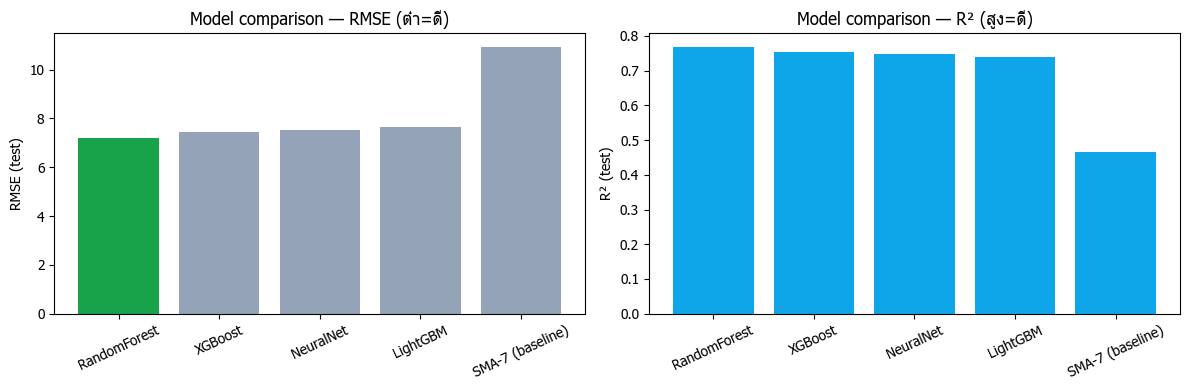

In [24]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(cmp['model'], cmp['RMSE'],
          color=['#16a34a' if m == winner else '#94a3b8' for m in cmp['model']])
ax[0].set_ylabel('RMSE (test)'); ax[0].set_title('Model comparison — RMSE (ต่ำ=ดี)')
ax[0].tick_params(axis='x', rotation=25)
ax[1].bar(cmp['model'], cmp['R2'], color='#0ea5e9')
ax[1].set_ylabel('R² (test)'); ax[1].set_title('Model comparison — R² (สูง=ดี)')
ax[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

## 3) Transportation Model (Lateral Transshipment)

Minimize `Z = ΣΣ c(i,j)·x(i,j)`  s.t. `Σ_j x(i,j) ≤ S(i)` (ต้นทาง), 
`Σ_i x(i,j) ≥ D(j)` (ปลายทาง), `x ≥ 0`  
โดย `c(i,j)` = ระยะทาง × transport_rate · `S(i)` = โดสเสี่ยงหมดอายุ (สถานะแดง ที่ขนส่งได้) · 
`D(j)` = ดีมานด์ที่ยังขาด

In [25]:
from numpy import radians, sin, cos, arccos, clip
master = pd.read_csv(ROOT / 'data' / 'hospitals' / 'hospital_master.csv')
branches = pd.read_csv(VAX / 'vaccine_branches.csv')
vials = pd.read_csv(VAX / 'clean' / 'vaccine_vial_clean.csv')
vials['effective_expiry'] = pd.to_datetime(vials['effective_expiry'], utc=True, format='ISO8601')
BR = list(branches['hospital_id'])
loc = master.set_index('hospital_id').loc[BR, ['latitude', 'longitude']]
rate = branches.set_index('hospital_id')['transport_rate']

def haversine(a, b):
    la1, lo1, la2, lo2 = map(radians, [loc.loc[a, 'latitude'], loc.loc[a, 'longitude'],
                                       loc.loc[b, 'latitude'], loc.loc[b, 'longitude']])
    return 6371 * arccos(clip(sin(la1) * sin(la2) + cos(la1) * cos(la2) * cos(lo2 - lo1), -1, 1))

# เลือก 1 ผลิตภัณฑ์มาเดโม (mRNA) — supply = โดสในขวดเสี่ยง (<=14 วัน) ที่ขนส่งได้ (ไม่ใช่ OPENED)
now = pd.Timestamp('2026-06-26T08:00:00+07:00')
vials['days_remaining'] = (vials['effective_expiry'] - now).dt.total_seconds() / 86400
pid = 'VAX_MRNA_01'
risk = vials[(vials.product_id == pid) & (vials.state != 'OPENED') & (vials.days_remaining <= 14)]
supply = risk.groupby('hospital_id')['doses_remaining'].sum().reindex(BR, fill_value=0)
# demand ปลายทาง = ดีมานด์เฉลี่ย 7 วันล่าสุดของผลิตภัณฑ์นี้
recent = feat[(feat.product_id == pid) & (feat.date >= feat.date.max() - pd.Timedelta(days=7))]
demand_j = recent.groupby('hospital_id')['demand'].mean().reindex(BR, fill_value=0).round()
print('supply (เสี่ยงหมดอายุ):', supply.to_dict())
print('demand (เฉลี่ย 7วัน):  ', demand_j.to_dict())

supply (เสี่ยงหมดอายุ): {'HOSP_001': 12, 'HOSP_002': 0, 'HOSP_003': 30, 'HOSP_004': 6, 'HOSP_005': 0}
demand (เฉลี่ย 7วัน):   {'HOSP_001': 17.0, 'HOSP_002': 16.0, 'HOSP_003': 32.0, 'HOSP_004': 20.0, 'HOSP_005': 17.0}


In [26]:
# สร้างเมทริกซ์ต้นทุน c(i,j) = ระยะทาง(กม.) * transport_rate(ปลายทาง)
n = len(BR)
C = np.zeros((n, n))
for i, si in enumerate(BR):
    for j, sj in enumerate(BR):
        C[i, j] = 0 if i == j else haversine(si, sj) * rate[sj]

# ตัวแปร x(i,j) แบนเป็นเวกเตอร์ — ลด ΣΣ c*x
c = C.flatten()
# ระบายของเสี่ยงทั้งหมดออกจากต้นทาง (equality): Σ_j x(i,j) = S(i)
A_eq, b_eq = [], []
for i in range(n):
    row = np.zeros(n * n); row[i * n:(i + 1) * n] = 1
    A_eq.append(row); b_eq.append(supply.iloc[i])
# ปลายทางรับได้ไม่เกินดีมานด์ (upper bound): Σ_i x(i,j) <= D(j)
A_ub, b_ub = [], []
for j in range(n):
    row = np.zeros(n * n)
    for i in range(n): row[i * n + j] = 1
    A_ub.append(row); b_ub.append(demand_j.iloc[j])
# ห้ามส่งหาตัวเอง (x(i,i)=0)
bounds = [(0, None) if i // n != i % n else (0, 0) for i in range(n * n)]
assert supply.sum() <= demand_j.sum(), 'supply เกิน demand รวม — ปรับ formulation'
res = linprog(c, A_ub=np.array(A_ub), b_ub=np.array(b_ub),
              A_eq=np.array(A_eq), b_eq=np.array(b_eq), bounds=bounds, method='highs')
print('LP status:', res.message, '| total cost Z =', round(res.fun or 0, 1))

LP status: Optimization terminated successfully. (HiGHS Status 7: Optimal) | total cost Z = 11718.4


In [27]:
plan = pd.DataFrame(res.x.reshape(n, n), index=BR, columns=BR).round(1)
moved = plan.stack().reset_index()
moved.columns = ['from_hospital', 'to_hospital', 'doses']
moved = moved[moved['doses'] > 0.5].sort_values('doses', ascending=False)
moved['product_id'] = pid
moved.to_csv(OUT / 'transshipment_plan.csv', index=False, encoding='utf-8-sig')
print(f'แผนโอนย้าย {pid}: {len(moved)} เส้นทาง · รวม {moved.doses.sum():.0f} โดส')
moved

แผนโอนย้าย VAX_MRNA_01: 4 เส้นทาง · รวม 48 โดส


,from_hospital,to_hospital,doses,product_id
10,HOSP_003,HOSP_001,17.0,VAX_MRNA_01
13,HOSP_003,HOSP_004,13.0,VAX_MRNA_01
2,HOSP_001,HOSP_003,12.0,VAX_MRNA_01
17,HOSP_004,HOSP_003,6.0,VAX_MRNA_01
